Saving train_revised.csv to train_revised (6).csv


/tmp/ipython-input-9-226677166.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='car_type', y='seats_sold', data=ride_df, palette='pastel')
/tmp/ipython-input-9-226677166.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='seats_sold', y='travel_from', data=ride_df, order=order_by_avg, palette='coolwarm')
/tmp/ipython-input-9-226677166.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='day_of_week', y='seats_sold', data=ride_df,
/tmp/ipython-input-9-226677166.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is

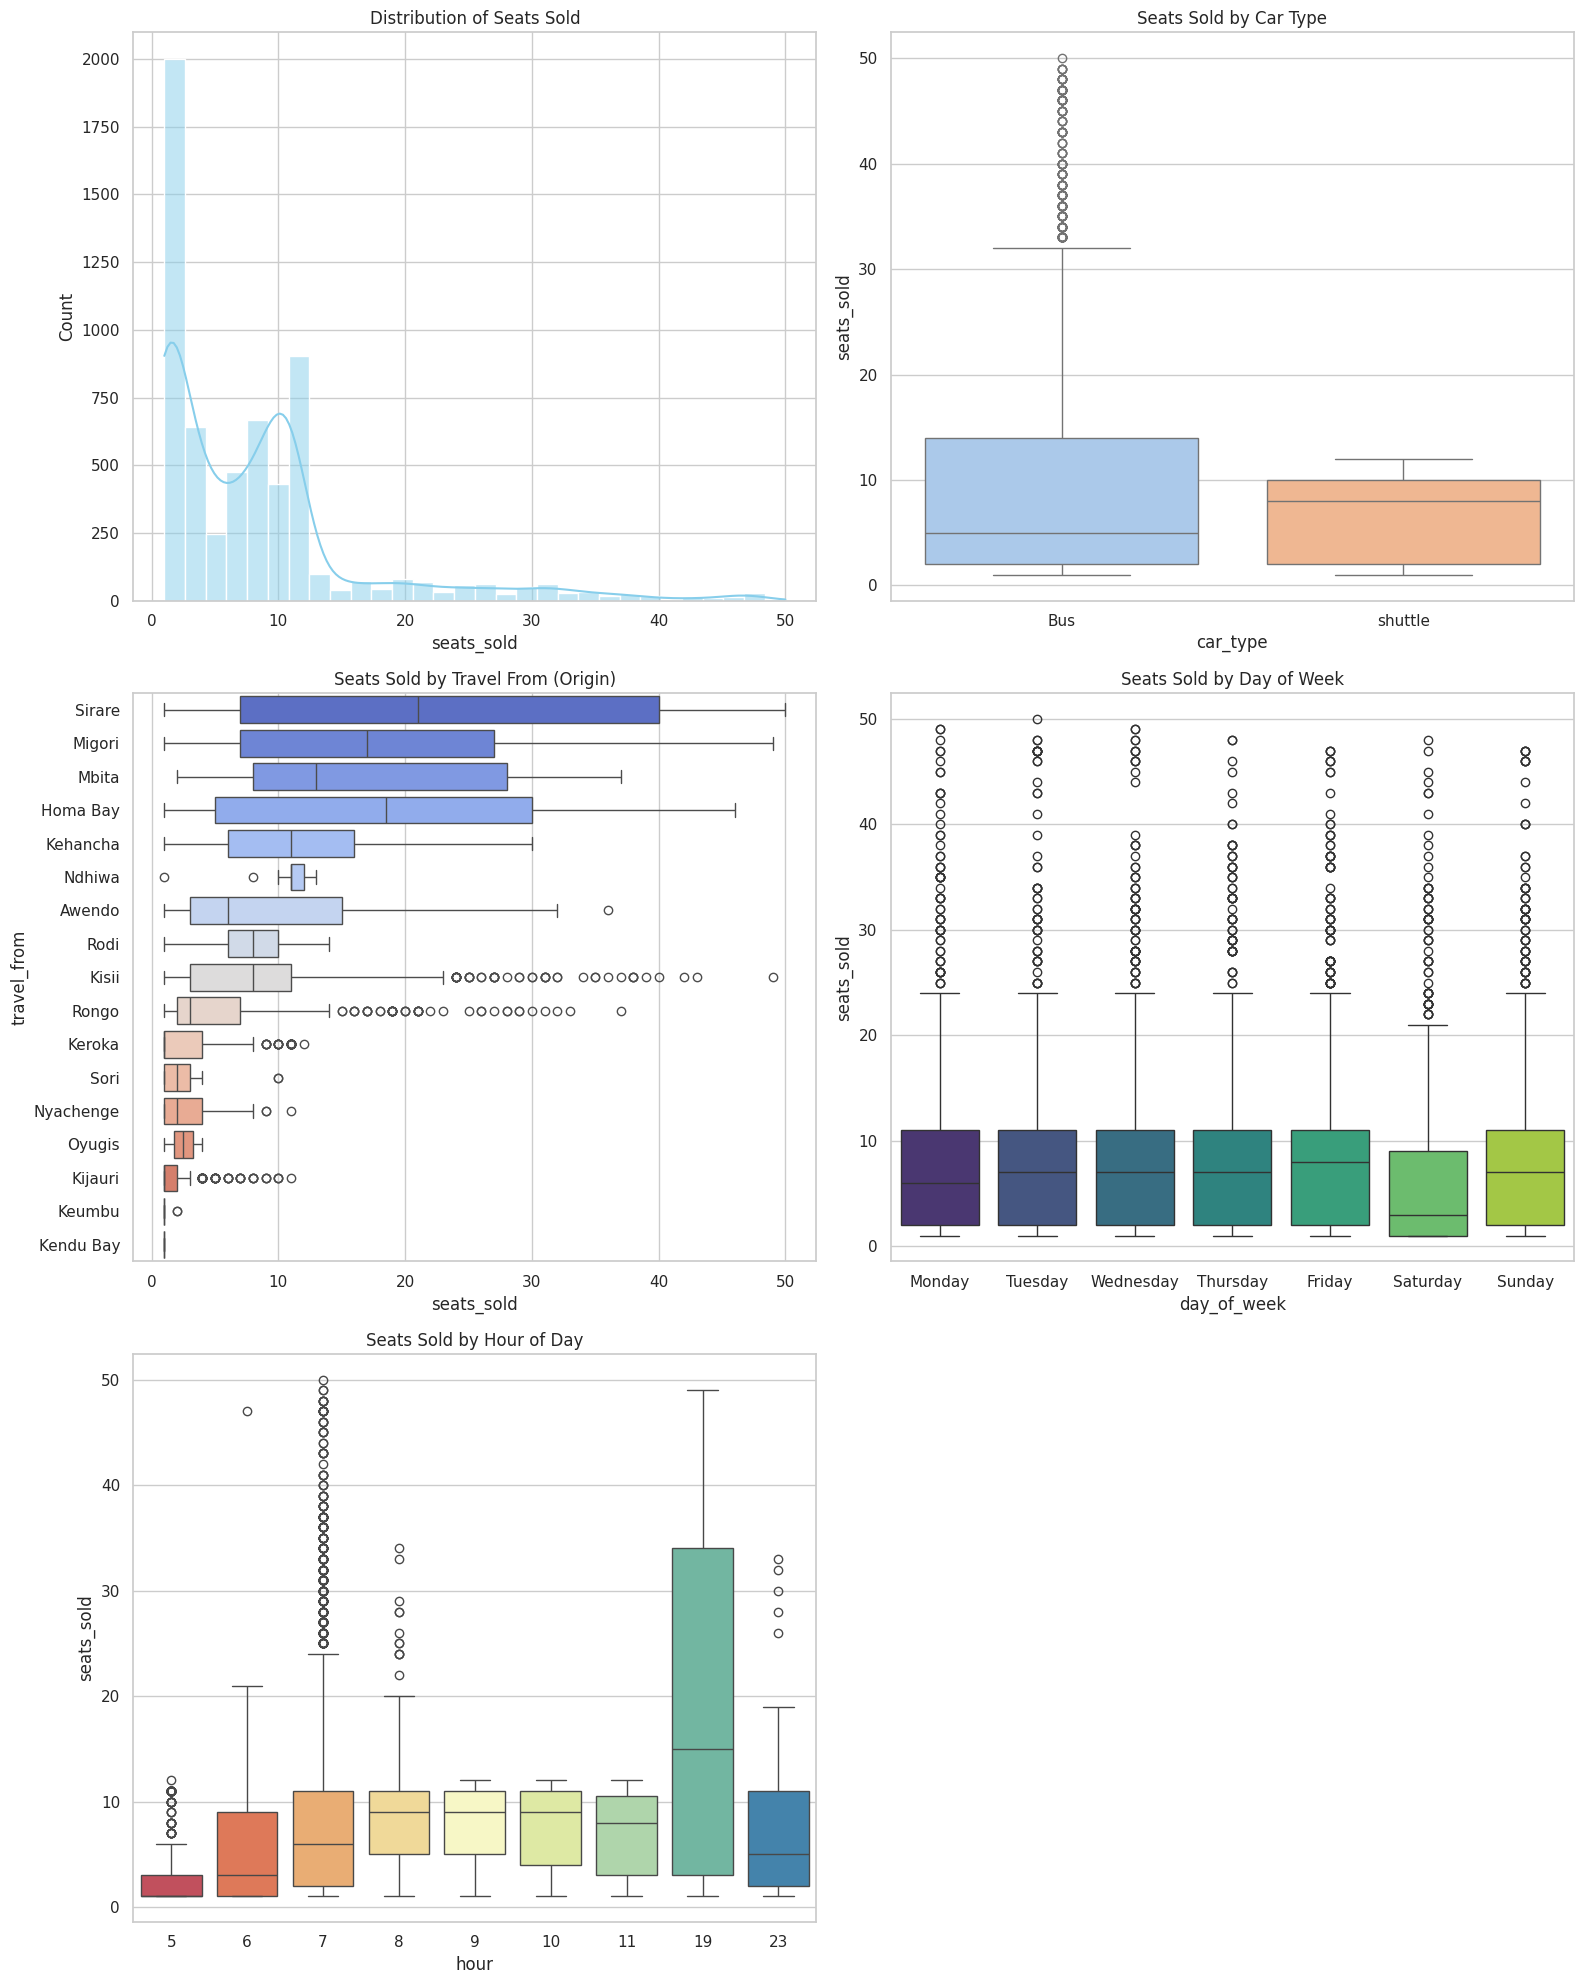

✅ Preprocessing done.
Train shape: (4999, 26)
Test shape: (1250, 26)
Linear Regression Results:
RMSE: 7.16
MAE: 4.90
R2 Score: 0.37
Random Forest Results:
RMSE: 7.15
MAE: 4.39
R2 Score: 0.37
XGBoost Results:
RMSE: 6.73
MAE: 4.37
R2 Score: 0.44


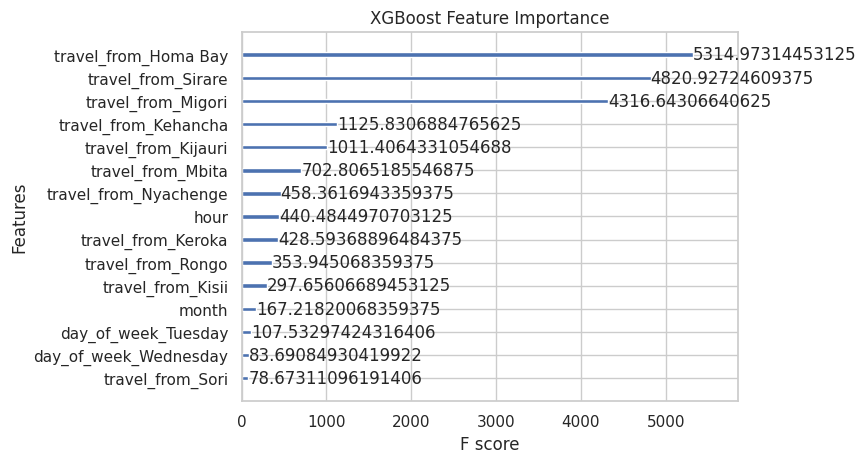

In [9]:
# STEP 1: Install and Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Upload the CSV from your local system
from google.colab import files
uploaded = files.upload()

# Load CSV into DataFrame
df = pd.read_csv('train_revised.csv')

# STEP 2: Preprocess & Transform to Ride-Level
df['travel_datetime'] = pd.to_datetime(df['travel_date'] + ' ' + df['travel_time'], format='%d-%m-%y %H:%M')

ride_df = df.groupby('ride_id').agg({
    'seat_number': 'count',
    'travel_from': 'first',
    'travel_to': 'first',
    'travel_datetime': 'first',
    'car_type': 'first',
    'max_capacity': 'first'
}).reset_index()

ride_df = ride_df.rename(columns={'seat_number': 'seats_sold'})

ride_df['day_of_week'] = ride_df['travel_datetime'].dt.day_name()
ride_df['hour'] = ride_df['travel_datetime'].dt.hour
ride_df['month'] = ride_df['travel_datetime'].dt.month

# STEP 3: EDA Visualizations
sns.set(style="whitegrid")
plt.figure(figsize=(16, 20))

# 1. Distribution of seats sold
plt.subplot(3, 2, 1)
sns.histplot(ride_df['seats_sold'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Seats Sold')

# 2. Seats sold by car type
plt.subplot(3, 2, 2)
sns.boxplot(x='car_type', y='seats_sold', data=ride_df, palette='pastel')
plt.title('Seats Sold by Car Type')

# 3. By town of origin
plt.subplot(3, 2, 3)
order_by_avg = ride_df.groupby('travel_from')['seats_sold'].mean().sort_values(ascending=False).index
sns.boxplot(x='seats_sold', y='travel_from', data=ride_df, order=order_by_avg, palette='coolwarm')
plt.title('Seats Sold by Travel From (Origin)')

# 4. By day of week
plt.subplot(3, 2, 4)
sns.boxplot(x='day_of_week', y='seats_sold', data=ride_df,
            order=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
            palette='viridis')
plt.title('Seats Sold by Day of Week')

# 5. By hour
plt.subplot(3, 2, 5)
sns.boxplot(x='hour', y='seats_sold', data=ride_df, palette='Spectral')
plt.title('Seats Sold by Hour of Day')

plt.tight_layout()
plt.show()
from sklearn.model_selection import train_test_split

# Drop constant column
ride_df = ride_df.drop(columns=['travel_to'])  # always 'Nairobi'

# One-hot encode travel_from, car_type, day_of_week
categorical_features = ['travel_from', 'car_type', 'day_of_week']
ride_encoded = pd.get_dummies(ride_df, columns=categorical_features, drop_first=True)

# Define X and y
X = ride_encoded.drop(columns=['ride_id', 'travel_datetime', 'seats_sold'])
y = ride_encoded['seats_sold']

# Split data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✅ Preprocessing done.")
print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

#Linear regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Step 1: create and train the model
linreg = LinearRegression()
linreg.fit(X_train, y_train)

# Step 2: predictions
y_pred = linreg.predict(X_test)

# Step 3: evaluation
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Linear Regression Results:")
print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R2 Score: {r2:.2f}")

#Random forest regressor
from sklearn.ensemble import RandomForestRegressor

# create and train
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# predictions
y_pred_rf = rf.predict(X_test)

# evaluation
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Results:")
print(f"RMSE: {rmse_rf:.2f}")
print(f"MAE: {mae_rf:.2f}")
print(f"R2 Score: {r2_rf:.2f}")

#XGBoost results
import xgboost as xgb

# define and fit the model
xgb_reg = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

xgb_reg.fit(X_train, y_train)

# predictions
y_pred_xgb = xgb_reg.predict(X_test)

# evaluation
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost Results:")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"MAE: {mae_xgb:.2f}")
print(f"R2 Score: {r2_xgb:.2f}")

import matplotlib.pyplot as plt

# plot feature importance
xgb.plot_importance(xgb_reg, max_num_features=15, importance_type='gain')
plt.title("XGBoost Feature Importance")
plt.show()

# Conclusion
- We built a regression model to predict seat demand for Mobiticket shuttle rides.
- Explored multiple models (Linear Regression, Random Forest, XGBoost).
- XGBoost performed best with RMSE 6.73 and R² 0.44.
- Routes such as Homa Bay, Sirare, and Migori showed highest influence on demand.
- Further improvements could include external features like holidays, events, or weather to boost prediction accuracy.




In [10]:
!pip install xgboost